Using device: cuda
** Test Dataset Loaded: 2130 images **
Loading weights from exp-4_1_3.pth...
✅ Model loaded successfully.

Evaluating Clean...
📊 Accuracy on Clean images: 80.05%
🔍 Classification Report (Clean):

              precision    recall  f1-score   support

    Adposhel       1.00      1.00      1.00        60
       Agent       0.54      0.78      0.64        50
     Allaple       0.98      0.98      0.98        53
   Amonetize       0.94      0.95      0.94        61
      Androm       0.83      0.97      0.90        62
     Autorun       0.68      0.80      0.74        61
   BrowseFox       0.73      0.93      0.82        60
      Dinwod       0.94      0.98      0.96        62
        Elex       0.95      1.00      0.98        62
      Expiro       0.52      0.70      0.59        63
      Fasong       0.97      1.00      0.98        62
     HackKMS       1.00      1.00      1.00        62
        Hlux       1.00      1.00      1.00        62
    Injector       0.93     

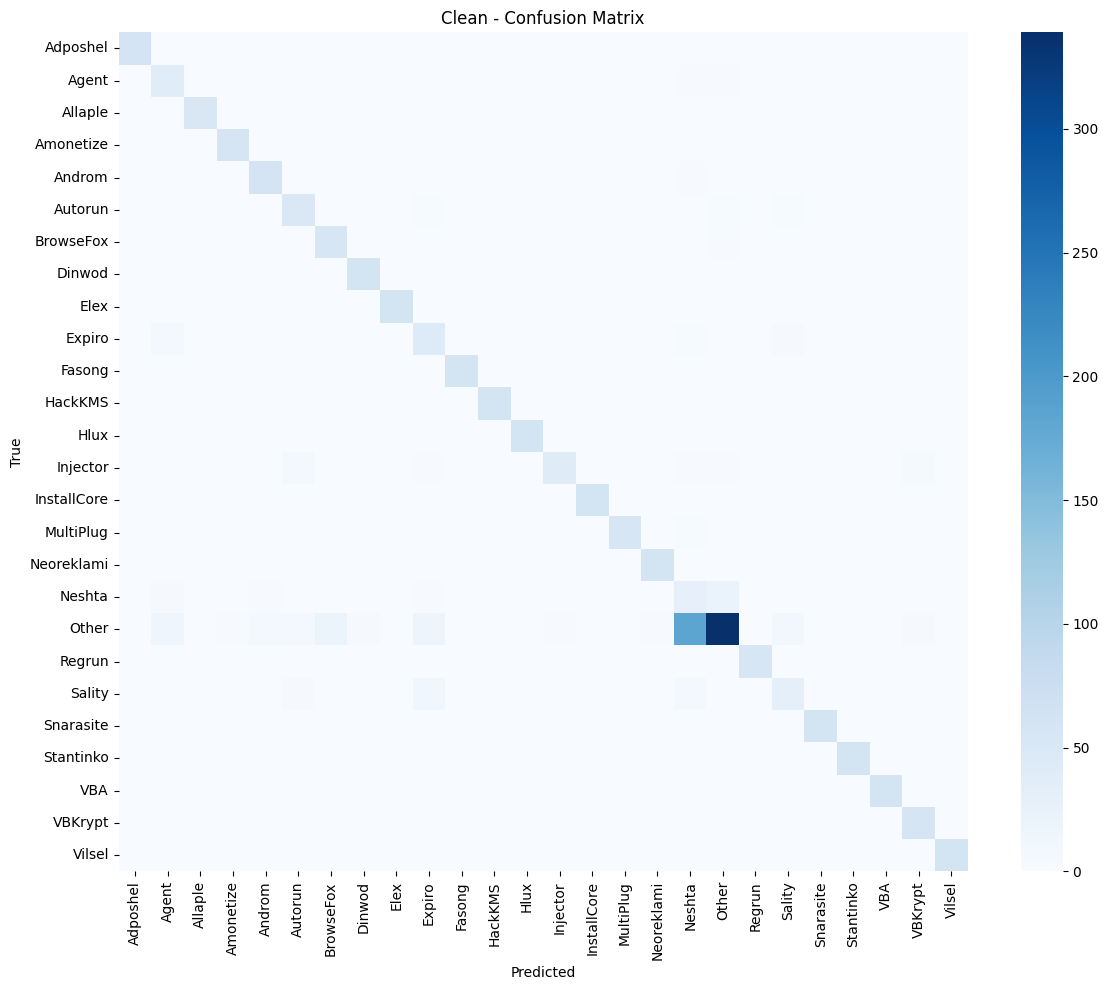


Evaluating FGSM...
📊 Accuracy on FGSM images: 38.40%
🔍 Classification Report (FGSM):

              precision    recall  f1-score   support

    Adposhel       0.98      1.00      0.99        60
       Agent       0.10      0.28      0.15        50
     Allaple       0.62      0.43      0.51        53
   Amonetize       0.37      0.36      0.37        61
      Androm       0.51      0.82      0.63        62
     Autorun       0.38      0.46      0.42        61
   BrowseFox       0.12      0.15      0.14        60
      Dinwod       0.27      0.45      0.34        62
        Elex       0.36      0.32      0.34        62
      Expiro       0.05      0.11      0.07        63
      Fasong       0.79      0.97      0.87        62
     HackKMS       0.61      0.66      0.64        62
        Hlux       0.97      1.00      0.98        62
    Injector       0.15      0.12      0.13        60
 InstallCore       0.81      0.84      0.83        62
   MultiPlug       0.51      0.52      0.51     

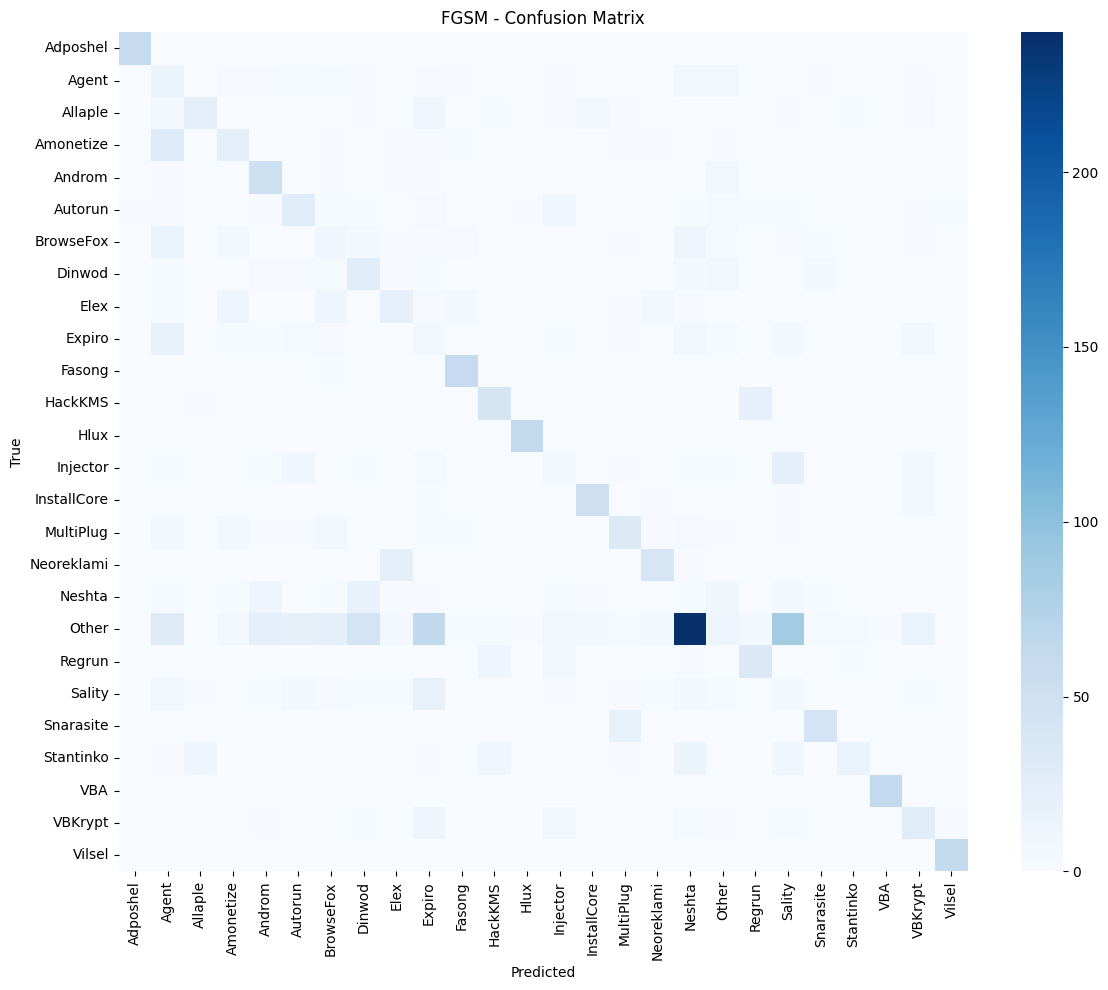


Evaluating PGD...
📊 Accuracy on PGD images: 5.96%
🔍 Classification Report (PGD):

              precision    recall  f1-score   support

    Adposhel       0.86      0.83      0.85        60
       Agent       0.00      0.00      0.00        50
     Allaple       0.03      0.02      0.02        53
   Amonetize       0.00      0.00      0.00        61
      Androm       0.00      0.00      0.00        62
     Autorun       0.00      0.00      0.00        61
   BrowseFox       0.00      0.00      0.00        60
      Dinwod       0.01      0.02      0.01        62
        Elex       0.00      0.00      0.00        62
      Expiro       0.00      0.00      0.00        63
      Fasong       0.00      0.00      0.00        62
     HackKMS       0.00      0.00      0.00        62
        Hlux       0.11      0.02      0.03        62
    Injector       0.00      0.00      0.00        60
 InstallCore       0.00      0.00      0.00        62
   MultiPlug       0.00      0.00      0.00        6

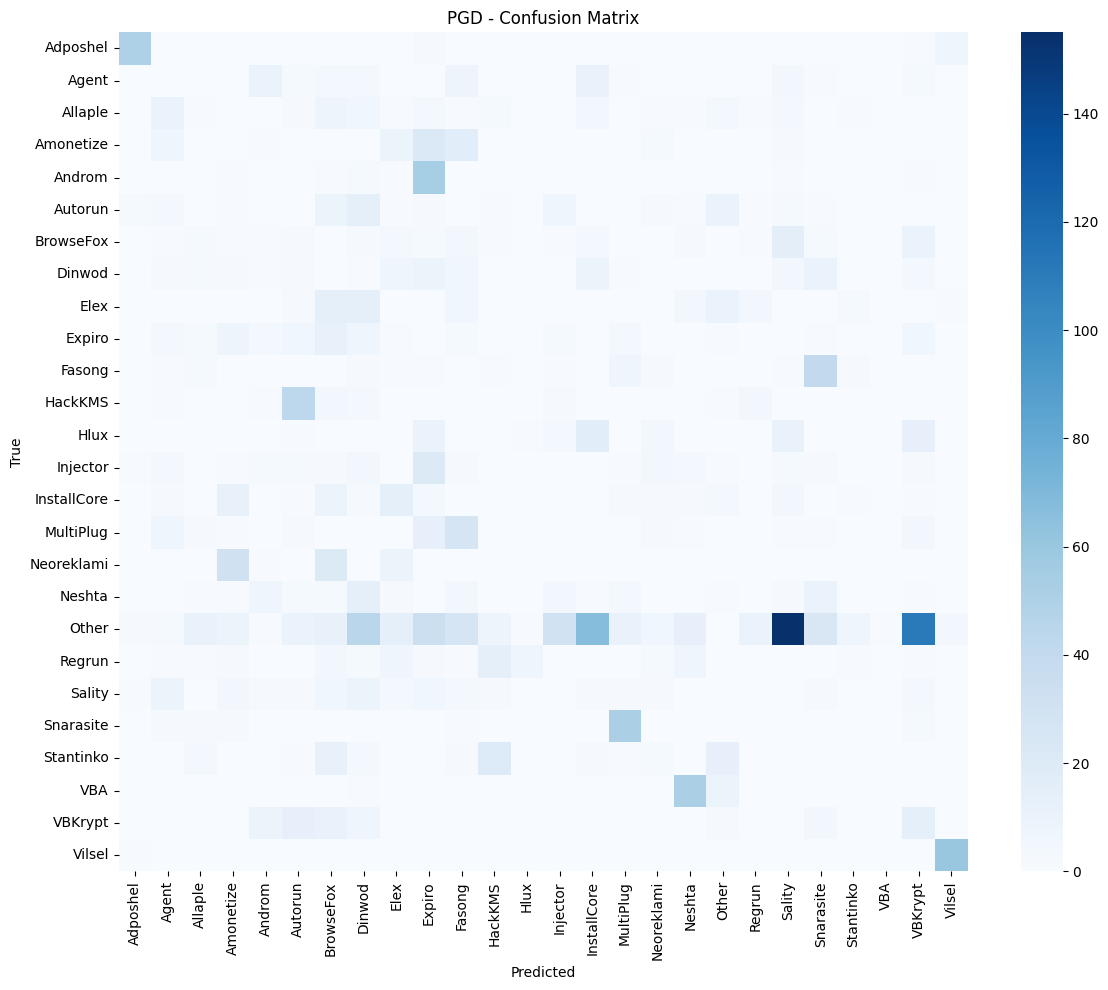

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
import pennylane as qml
from pennylane.qnn import TorchLayer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

# ========== CONFIGURATION ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

n_qubits = 10
num_classes = 26
batch_size = 16

# Path to your saved model
MODEL_PATH = "exp-4_1_3.pth" 

# Dataset Path
TEST_PATH = '/home/netsec1/Kathan/MaleVis 2 dataset/malevis_train_val_300x300/test'

# ========== DATA LOADING (Grayscale) ==========
eval_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

try:
    test_dataset = ImageFolder(TEST_PATH, transform=eval_transform)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    class_names = test_dataset.classes
    print(f"** Test Dataset Loaded: {len(test_dataset)} images **")
except Exception as e:
    print(f"Error loading dataset: {e}")
    # Dummy setup for code structure verification if path fails
    class_names = [str(i) for i in range(num_classes)]
    test_loader = None

# ========== MODEL ARCHITECTURE ==========
# (Must match the architecture of the saved checkpoint)

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    for i in range(n_qubits):
        qml.RY(inputs[..., i], wires=i)
    for l in range(weights.shape[0]):
        for i in range(n_qubits):
            qml.RY(weights[l][i], wires=i)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes = {"weights": (6, n_qubits)}

class FeatureReduce(nn.Module):
    def __init__(self, final_dim, dropout=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=2, padding=1),    
            nn.BatchNorm2d(8), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv2d(8, 16, 3, stride=2, padding=1),   
            nn.BatchNorm2d(16), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),  
            nn.BatchNorm2d(32), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  
            nn.BatchNorm2d(64), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), 
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 224, 3, stride=2, padding=1), 
            nn.BatchNorm2d(224), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))                
        )
        self.fc_expand = nn.Linear(224, final_dim * 2)
        self.fc_project = nn.Linear(final_dim * 2, final_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc_expand(x))
        return self.fc_project(x)

class HybridQNN(nn.Module):
    def __init__(self, n_qubits, num_classes):
        super().__init__()
        self.feature_extractor = FeatureReduce(final_dim=n_qubits)
        self.q_layer = TorchLayer(quantum_circuit, weight_shapes)
        self.classifier = nn.Sequential(
            nn.Linear(n_qubits, 64),
            nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(64, 32),
            nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.tanh(x)
        q_out = self.q_layer(x) 
        return self.classifier(q_out)

# ========== ATTACK FUNCTIONS ==========

def fgsm_attack(model, images, labels, eps_fgsm=0.03, device='cuda'):
    """Generate FGSM adversarial examples."""
    model.eval()
    images_adv = images.clone().detach().to(device).requires_grad_(True)
    labels = labels.to(device)

    logits = model(images_adv)
    loss = F.cross_entropy(logits, labels)
    model.zero_grad()
    loss.backward()

    images_adv = images_adv + eps_fgsm * images_adv.grad.sign()
    images_adv = torch.clamp(images_adv, min=-1.0, max=1.0)
    return images_adv.detach()

def pgd_attack(model, images, labels, pgd_eps=0.1, pgd_alpha=0.01, pgd_iters=7, device='cuda'):
    """Generate PGD adversarial examples."""
    model.eval()
    images_orig = images.clone().detach().to(device)
    labels = labels.to(device)

    images_adv = images_orig + torch.empty_like(images_orig).uniform_(-pgd_eps, pgd_eps)
    images_adv = torch.clamp(images_adv, -1.0, 1.0).detach()

    for _ in range(pgd_iters):
        images_adv.requires_grad_(True)
        logits = model(images_adv)
        loss = F.cross_entropy(logits, labels)
        model.zero_grad()
        loss.backward()

        perturb = pgd_alpha * images_adv.grad.sign()
        images_adv = images_adv + perturb
        
        delta = torch.clamp(images_adv - images_orig, min=-pgd_eps, max=pgd_eps)
        images_adv = torch.clamp(images_orig + delta, -1.0, 1.0).detach()

    return images_adv

# ========== EVALUATION FUNCTION ==========

def evaluate_attack(model, loader, attack_fn=None, attack_name="Clean", **kwargs):
    if loader is None:
        print("Loader is None. Skipping evaluation.")
        return

    model.eval()
    all_preds, all_labels = [], []
    
    print(f"\nEvaluating {attack_name}...")

    # Iterate over batches
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        # Apply Attack if specified
        if attack_fn:
            xb = attack_fn(model, xb, yb, device=device, **kwargs)

        # Prediction
        with torch.no_grad():
            logits = model(xb)
            preds = logits.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

    # Metrics
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"📊 Accuracy on {attack_name} images: {acc*100:.2f}%")
    
    print(f"🔍 Classification Report ({attack_name}):\n")
    # Using zero_division=0 to handle potential missing classes in batch
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{attack_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    return acc

# ========== MAIN EXECUTION ==========

if __name__ == "__main__":
    # 1. Initialize Model
    model = HybridQNN(n_qubits=n_qubits, num_classes=num_classes).to(device)

    # 2. Load Weights
    if os.path.exists(MODEL_PATH):
        print(f"Loading weights from {MODEL_PATH}...")
        try:
            model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
            print("✅ Model loaded successfully.")
        except Exception as e:
            print(f"❌ Failed to load weights: {e}")
            exit()
    else:
        print(f"❌ Model file not found at {MODEL_PATH}")
        exit()

    # 3. Run Evaluations
    
    # A) Clean Evaluation
    evaluate_attack(model, test_loader, attack_fn=None, attack_name="Clean")

    # B) FGSM Evaluation
    evaluate_attack(model, test_loader, attack_fn=fgsm_attack, attack_name="FGSM", 
                    eps_fgsm=0.03)

    # C) PGD Evaluation
    evaluate_attack(model, test_loader, attack_fn=pgd_attack, attack_name="PGD",
                    pgd_eps=0.1, pgd_alpha=0.01, pgd_iters=7)

Using device: cuda
** Test Dataset Loaded: 2130 images **
Loading weights from qni_ccp-3_continued.pth...
✅ Model loaded successfully.

Evaluating Clean...
📊 Accuracy on Clean images: 79.81%
🔍 Classification Report (Clean):

              precision    recall  f1-score   support

    Adposhel       0.98      1.00      0.99        60
       Agent       0.53      0.84      0.65        50
     Allaple       1.00      0.91      0.95        53
   Amonetize       0.87      0.97      0.91        61
      Androm       0.94      0.95      0.94        62
     Autorun       0.60      0.87      0.71        61
   BrowseFox       0.81      0.92      0.86        60
      Dinwod       1.00      0.94      0.97        62
        Elex       0.94      1.00      0.97        62
      Expiro       0.53      0.49      0.51        63
      Fasong       0.97      1.00      0.98        62
     HackKMS       0.98      1.00      0.99        62
        Hlux       0.95      1.00      0.98        62
    Injector      

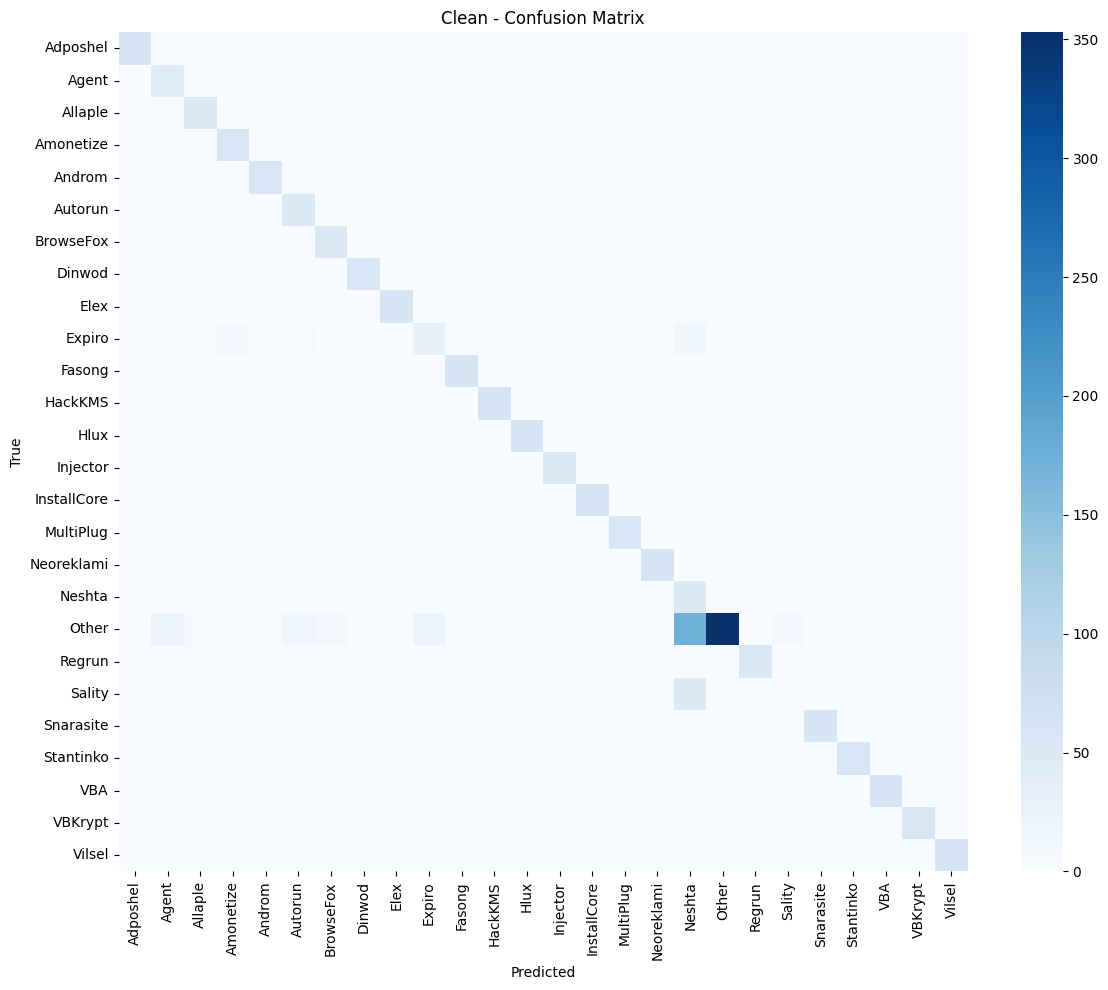


Evaluating FGSM...
📊 Accuracy on FGSM images: 14.60%
🔍 Classification Report (FGSM):

              precision    recall  f1-score   support

    Adposhel       0.77      0.83      0.80        60
       Agent       0.01      0.02      0.01        50
     Allaple       0.25      0.02      0.04        53
   Amonetize       0.03      0.02      0.02        61
      Androm       0.00      0.00      0.00        62
     Autorun       0.00      0.00      0.00        61
   BrowseFox       0.21      0.77      0.34        60
      Dinwod       0.00      0.00      0.00        62
        Elex       0.13      0.15      0.14        62
      Expiro       0.00      0.00      0.00        63
      Fasong       0.35      0.15      0.20        62
     HackKMS       0.00      0.00      0.00        62
        Hlux       0.00      0.00      0.00        62
    Injector       0.00      0.00      0.00        60
 InstallCore       0.25      0.45      0.32        62
   MultiPlug       0.19      0.13      0.15     

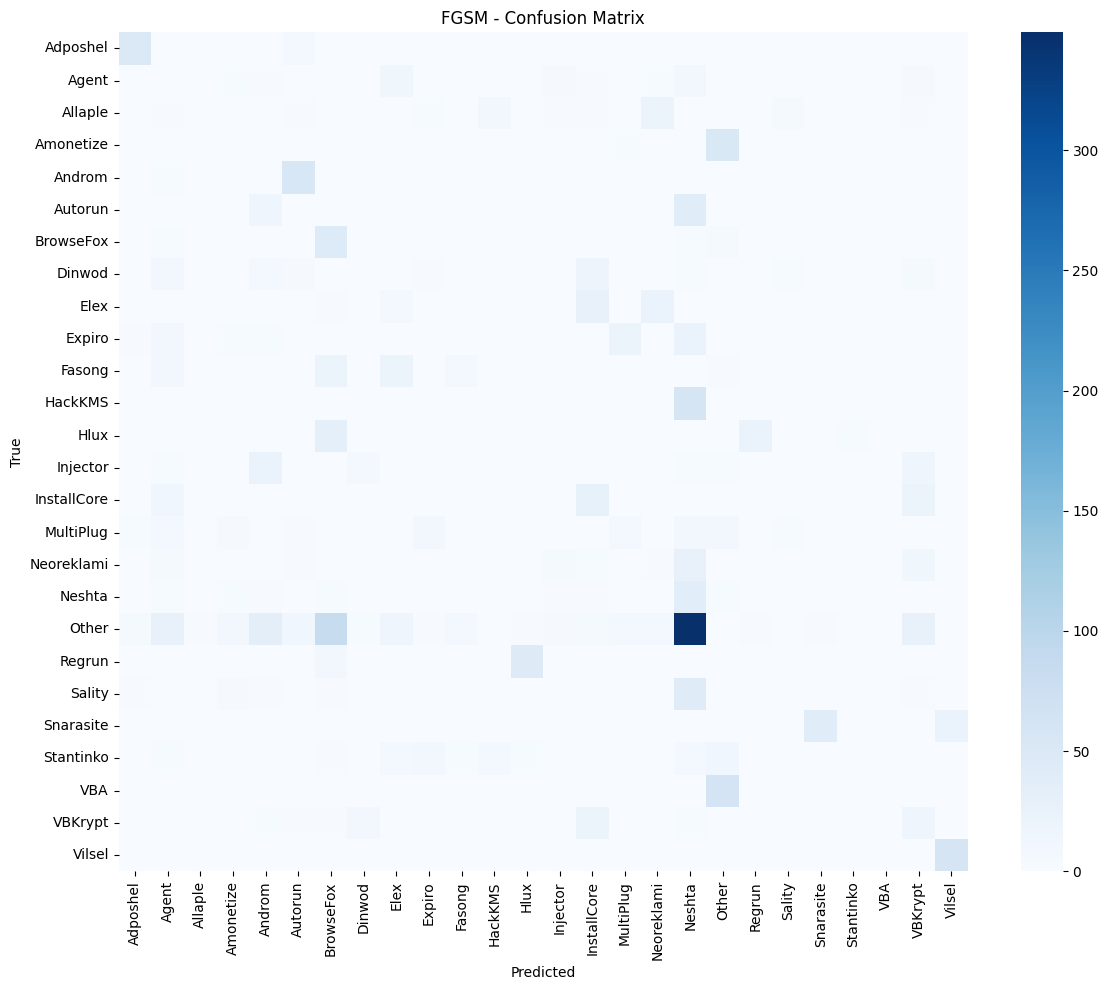


Evaluating PGD...
📊 Accuracy on PGD images: 4.69%
🔍 Classification Report (PGD):

              precision    recall  f1-score   support

    Adposhel       0.00      0.00      0.00        60
       Agent       0.00      0.00      0.00        50
     Allaple       0.00      0.00      0.00        53
   Amonetize       0.00      0.00      0.00        61
      Androm       0.00      0.00      0.00        62
     Autorun       0.00      0.00      0.00        61
   BrowseFox       0.12      0.58      0.19        60
      Dinwod       0.00      0.00      0.00        62
        Elex       0.00      0.00      0.00        62
      Expiro       0.00      0.00      0.00        63
      Fasong       0.00      0.00      0.00        62
     HackKMS       0.00      0.00      0.00        62
        Hlux       0.00      0.00      0.00        62
    Injector       0.00      0.00      0.00        60
 InstallCore       0.01      0.03      0.02        62
   MultiPlug       0.00      0.00      0.00        6

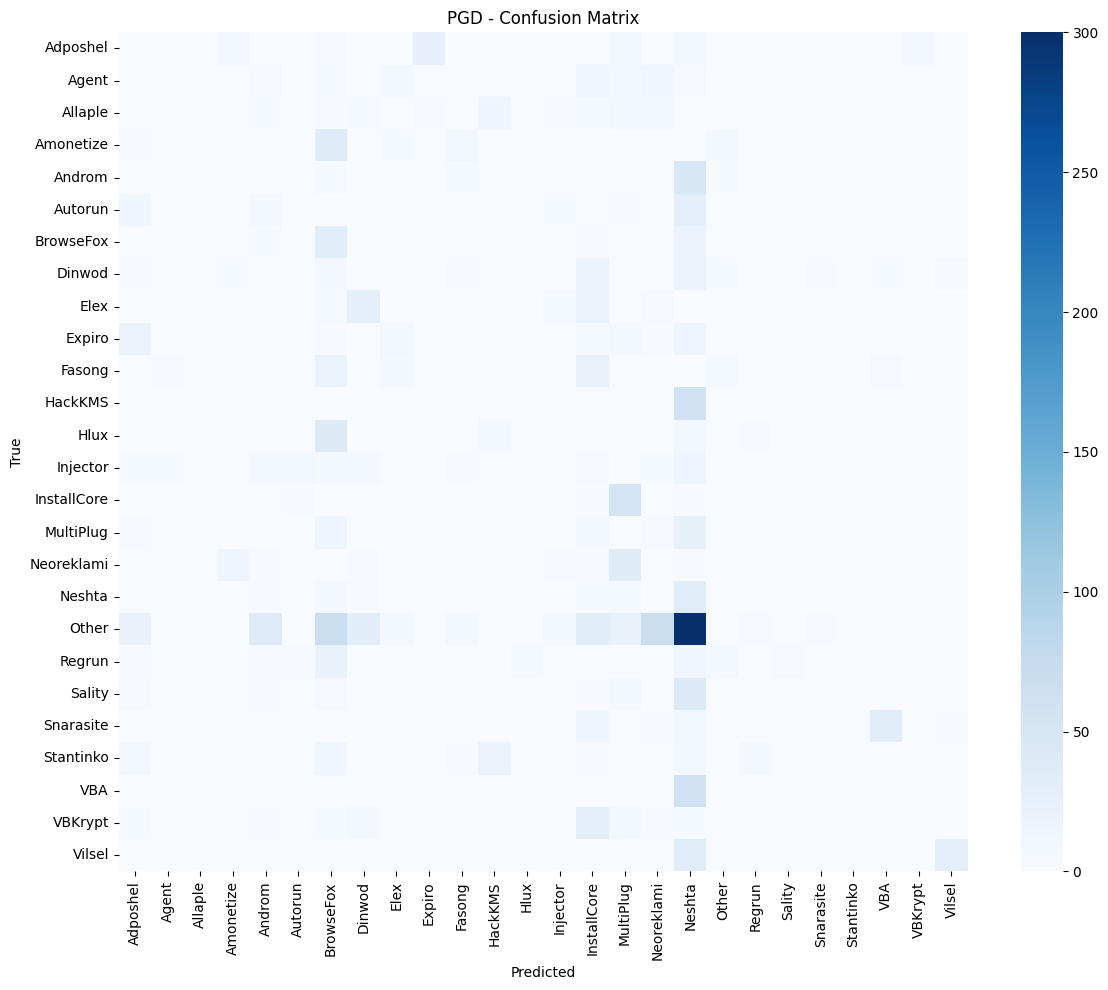

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
import pennylane as qml
from pennylane.qnn import TorchLayer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

# ========== CONFIGURATION ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

n_qubits = 10
num_classes = 26
batch_size = 16

# Path to your saved model
MODEL_PATH = "qni_ccp-3_continued.pth" 

# Dataset Path
TEST_PATH = '/home/netsec1/Kathan/MaleVis 2 dataset/malevis_train_val_300x300/test'

# ========== DATA LOADING (Grayscale) ==========
eval_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

try:
    test_dataset = ImageFolder(TEST_PATH, transform=eval_transform)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    class_names = test_dataset.classes
    print(f"** Test Dataset Loaded: {len(test_dataset)} images **")
except Exception as e:
    print(f"Error loading dataset: {e}")
    # Dummy setup for code structure verification if path fails
    class_names = [str(i) for i in range(num_classes)]
    test_loader = None

# ========== MODEL ARCHITECTURE ==========
# (Must match the architecture of the saved checkpoint)

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    for i in range(n_qubits):
        qml.RY(inputs[..., i], wires=i)
    for l in range(weights.shape[0]):
        for i in range(n_qubits):
            qml.RY(weights[l][i], wires=i)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes = {"weights": (6, n_qubits)}

class FeatureReduce(nn.Module):
    def __init__(self, final_dim, dropout=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=2, padding=1),    
            nn.BatchNorm2d(8), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv2d(8, 16, 3, stride=2, padding=1),   
            nn.BatchNorm2d(16), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),  
            nn.BatchNorm2d(32), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  
            nn.BatchNorm2d(64), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), 
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 224, 3, stride=2, padding=1), 
            nn.BatchNorm2d(224), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))                
        )
        self.fc_expand = nn.Linear(224, final_dim * 2)
        self.fc_project = nn.Linear(final_dim * 2, final_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc_expand(x))
        return self.fc_project(x)

class HybridQNN(nn.Module):
    def __init__(self, n_qubits, num_classes):
        super().__init__()
        self.feature_extractor = FeatureReduce(final_dim=n_qubits)
        self.q_layer = TorchLayer(quantum_circuit, weight_shapes)
        self.classifier = nn.Sequential(
            nn.Linear(n_qubits, 64),
            nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(64, 32),
            nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.tanh(x)
        q_out = self.q_layer(x) 
        return self.classifier(q_out)

# ========== ATTACK FUNCTIONS ==========

def fgsm_attack(model, images, labels, eps_fgsm=0.03, device='cuda'):
    """Generate FGSM adversarial examples."""
    model.eval()
    images_adv = images.clone().detach().to(device).requires_grad_(True)
    labels = labels.to(device)

    logits = model(images_adv)
    loss = F.cross_entropy(logits, labels)
    model.zero_grad()
    loss.backward()

    images_adv = images_adv + eps_fgsm * images_adv.grad.sign()
    images_adv = torch.clamp(images_adv, min=-1.0, max=1.0)
    return images_adv.detach()

def pgd_attack(model, images, labels, pgd_eps=0.1, pgd_alpha=0.01, pgd_iters=7, device='cuda'):
    """Generate PGD adversarial examples."""
    model.eval()
    images_orig = images.clone().detach().to(device)
    labels = labels.to(device)

    images_adv = images_orig + torch.empty_like(images_orig).uniform_(-pgd_eps, pgd_eps)
    images_adv = torch.clamp(images_adv, -1.0, 1.0).detach()

    for _ in range(pgd_iters):
        images_adv.requires_grad_(True)
        logits = model(images_adv)
        loss = F.cross_entropy(logits, labels)
        model.zero_grad()
        loss.backward()

        perturb = pgd_alpha * images_adv.grad.sign()
        images_adv = images_adv + perturb
        
        delta = torch.clamp(images_adv - images_orig, min=-pgd_eps, max=pgd_eps)
        images_adv = torch.clamp(images_orig + delta, -1.0, 1.0).detach()

    return images_adv

# ========== EVALUATION FUNCTION ==========

def evaluate_attack(model, loader, attack_fn=None, attack_name="Clean", **kwargs):
    if loader is None:
        print("Loader is None. Skipping evaluation.")
        return

    model.eval()
    all_preds, all_labels = [], []
    
    print(f"\nEvaluating {attack_name}...")

    # Iterate over batches
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        # Apply Attack if specified
        if attack_fn:
            xb = attack_fn(model, xb, yb, device=device, **kwargs)

        # Prediction
        with torch.no_grad():
            logits = model(xb)
            preds = logits.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

    # Metrics
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"📊 Accuracy on {attack_name} images: {acc*100:.2f}%")
    
    print(f"🔍 Classification Report ({attack_name}):\n")
    # Using zero_division=0 to handle potential missing classes in batch
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{attack_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    return acc

# ========== MAIN EXECUTION ==========

if __name__ == "__main__":
    # 1. Initialize Model
    model = HybridQNN(n_qubits=n_qubits, num_classes=num_classes).to(device)

    # 2. Load Weights
    if os.path.exists(MODEL_PATH):
        print(f"Loading weights from {MODEL_PATH}...")
        try:
            model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
            print("✅ Model loaded successfully.")
        except Exception as e:
            print(f"❌ Failed to load weights: {e}")
            exit()
    else:
        print(f"❌ Model file not found at {MODEL_PATH}")
        exit()

    # 3. Run Evaluations
    
    # A) Clean Evaluation
    evaluate_attack(model, test_loader, attack_fn=None, attack_name="Clean")

    # B) FGSM Evaluation
    evaluate_attack(model, test_loader, attack_fn=fgsm_attack, attack_name="FGSM", 
                    eps_fgsm=0.03)

    # C) PGD Evaluation
    evaluate_attack(model, test_loader, attack_fn=pgd_attack, attack_name="PGD",
                    pgd_eps=0.1, pgd_alpha=0.01, pgd_iters=7)

Using device: cuda
** Test Dataset Loaded: 2130 images **
Loading weights from adv2.pth...
✅ Model loaded successfully.

Evaluating Clean...
📊 Accuracy on Clean images: 81.60%
🔍 Classification Report (Clean):

              precision    recall  f1-score   support

    Adposhel       1.00      1.00      1.00        60
       Agent       0.69      0.70      0.69        50
     Allaple       0.83      0.91      0.86        53
   Amonetize       0.97      0.97      0.97        61
      Androm       0.74      0.98      0.85        62
     Autorun       0.89      0.79      0.83        61
   BrowseFox       0.82      0.93      0.88        60
      Dinwod       1.00      0.97      0.98        62
        Elex       1.00      0.97      0.98        62
      Expiro       0.39      0.76      0.51        63
      Fasong       1.00      1.00      1.00        62
     HackKMS       1.00      1.00      1.00        62
        Hlux       1.00      1.00      1.00        62
    Injector       1.00      0.73

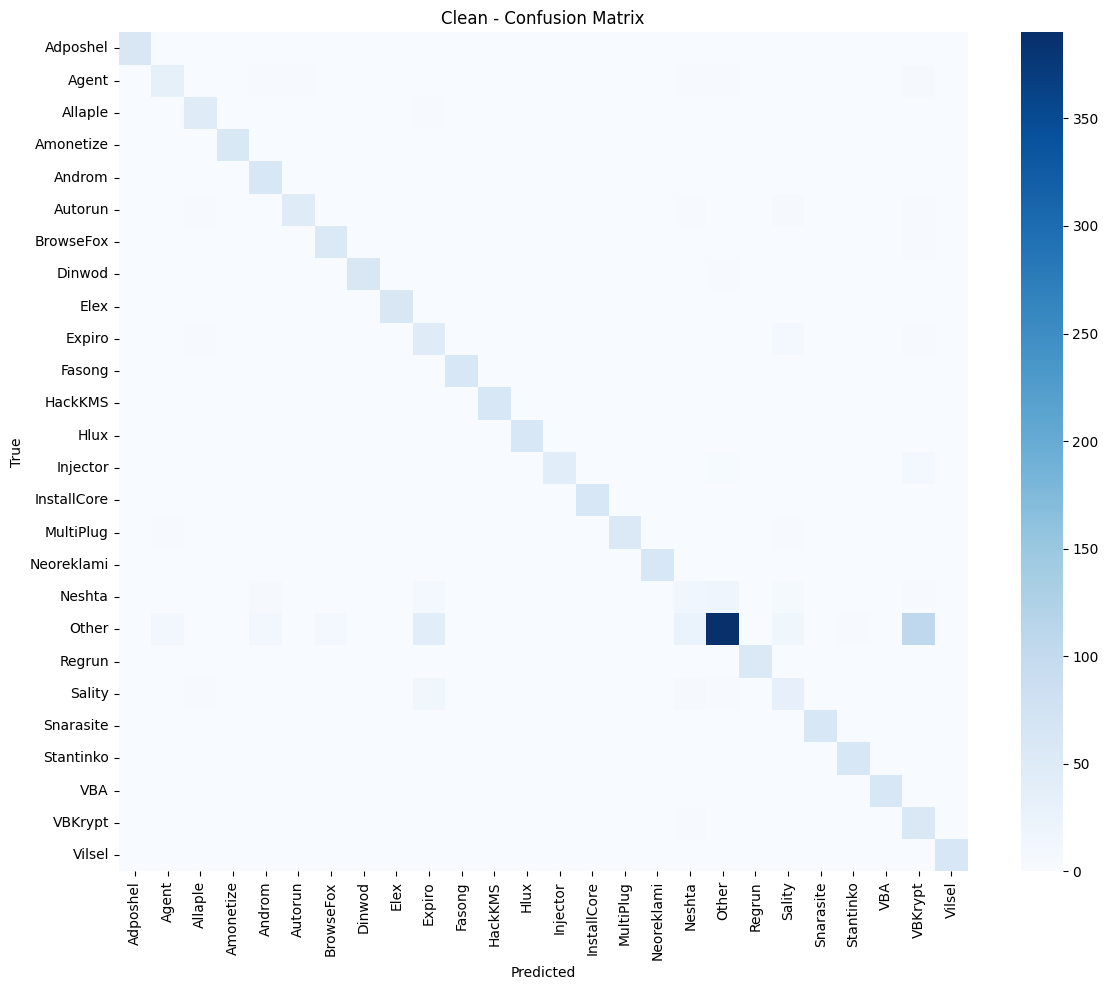


Evaluating FGSM...
📊 Accuracy on FGSM images: 74.98%
🔍 Classification Report (FGSM):

              precision    recall  f1-score   support

    Adposhel       1.00      1.00      1.00        60
       Agent       0.70      0.60      0.65        50
     Allaple       0.64      0.83      0.72        53
   Amonetize       0.92      0.93      0.93        61
      Androm       0.63      0.95      0.76        62
     Autorun       0.77      0.77      0.77        61
   BrowseFox       0.68      0.90      0.77        60
      Dinwod       0.91      0.94      0.92        62
        Elex       0.97      0.97      0.97        62
      Expiro       0.26      0.57      0.35        63
      Fasong       1.00      1.00      1.00        62
     HackKMS       1.00      1.00      1.00        62
        Hlux       1.00      1.00      1.00        62
    Injector       1.00      0.60      0.75        60
 InstallCore       0.98      0.98      0.98        62
   MultiPlug       0.84      0.87      0.86     

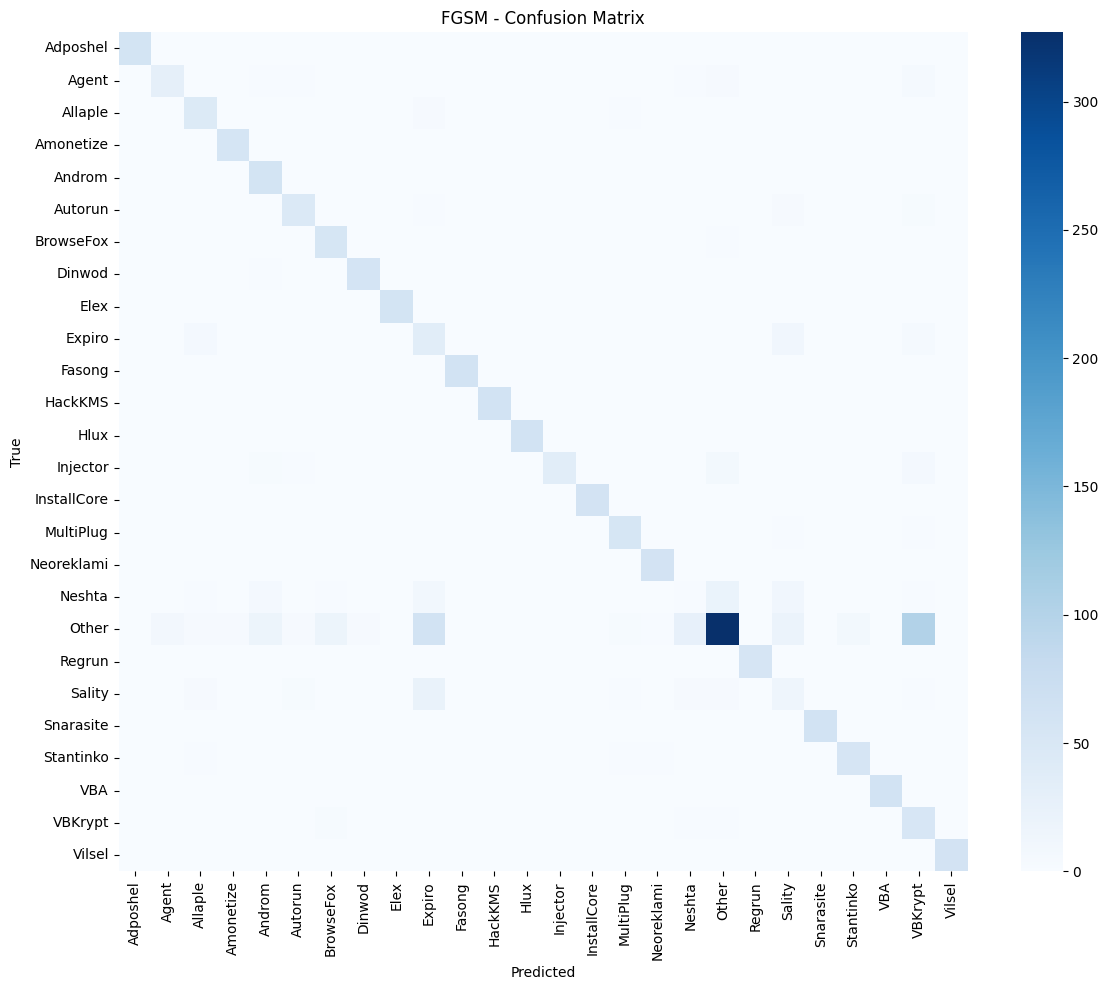


Evaluating PGD...
📊 Accuracy on PGD images: 66.95%
🔍 Classification Report (PGD):

              precision    recall  f1-score   support

    Adposhel       1.00      1.00      1.00        60
       Agent       0.66      0.54      0.59        50
     Allaple       0.47      0.64      0.54        53
   Amonetize       0.92      0.93      0.93        61
      Androm       0.55      0.94      0.69        62
     Autorun       0.68      0.69      0.68        61
   BrowseFox       0.43      0.82      0.56        60
      Dinwod       0.82      0.89      0.85        62
        Elex       0.94      0.95      0.94        62
      Expiro       0.08      0.17      0.11        63
      Fasong       0.98      1.00      0.99        62
     HackKMS       1.00      1.00      1.00        62
        Hlux       0.93      1.00      0.96        62
    Injector       0.97      0.55      0.70        60
 InstallCore       0.98      0.95      0.97        62
   MultiPlug       0.81      0.82      0.82        

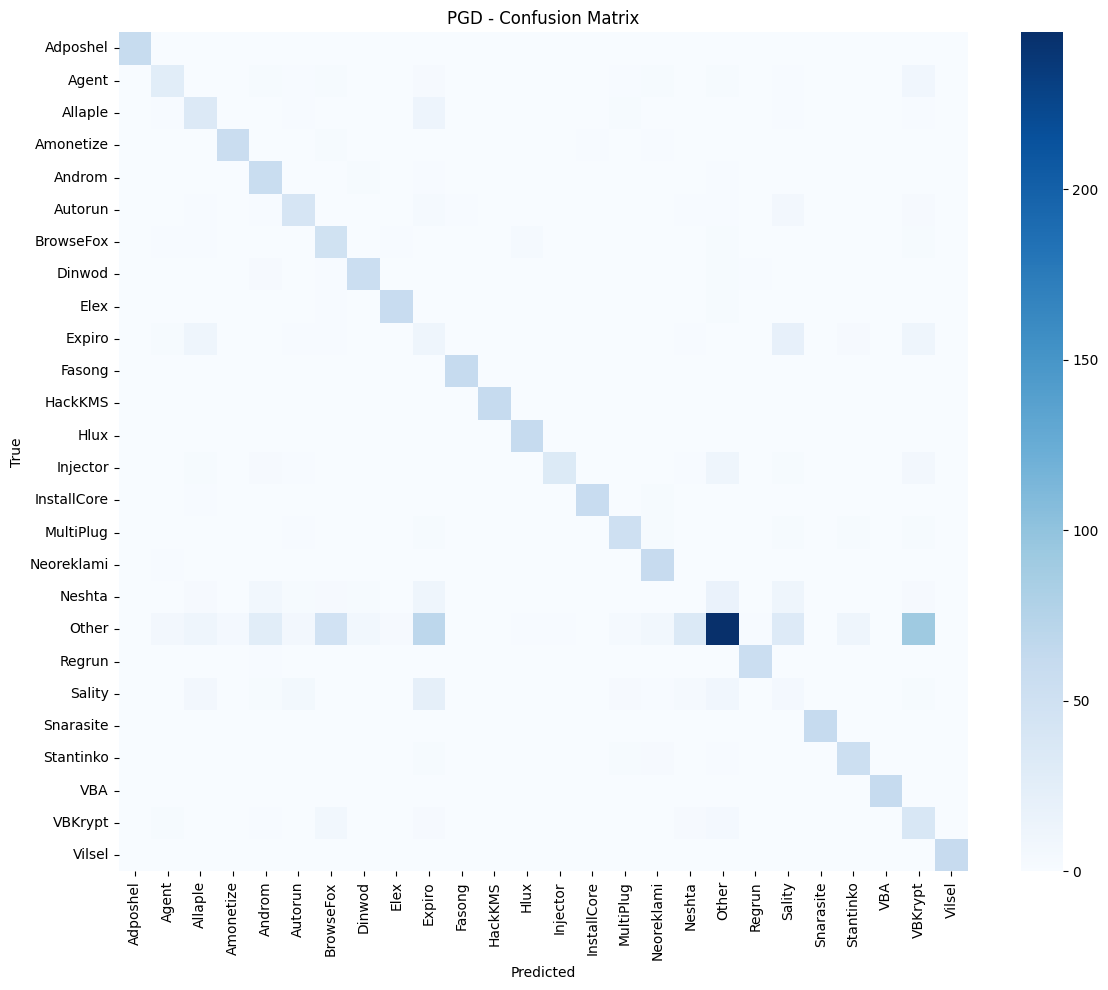

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
import pennylane as qml
from pennylane.qnn import TorchLayer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

# ========== CONFIGURATION ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

n_qubits = 10
num_classes = 26
batch_size = 16

# Path to your saved model
MODEL_PATH = "adv2.pth" 

# Dataset Path
TEST_PATH = '/home/netsec1/Kathan/MaleVis 2 dataset/malevis_train_val_300x300/test'

# ========== DATA LOADING (Grayscale) ==========
eval_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

try:
    test_dataset = ImageFolder(TEST_PATH, transform=eval_transform)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    class_names = test_dataset.classes
    print(f"** Test Dataset Loaded: {len(test_dataset)} images **")
except Exception as e:
    print(f"Error loading dataset: {e}")
    # Dummy setup for code structure verification if path fails
    class_names = [str(i) for i in range(num_classes)]
    test_loader = None

# ========== MODEL ARCHITECTURE ==========
# (Must match the architecture of the saved checkpoint)

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    for i in range(n_qubits):
        qml.RY(inputs[..., i], wires=i)
    for l in range(weights.shape[0]):
        for i in range(n_qubits):
            qml.RY(weights[l][i], wires=i)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes = {"weights": (6, n_qubits)}

class FeatureReduce(nn.Module):
    def __init__(self, final_dim, dropout=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=2, padding=1),    
            nn.BatchNorm2d(8), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv2d(8, 16, 3, stride=2, padding=1),   
            nn.BatchNorm2d(16), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),  
            nn.BatchNorm2d(32), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  
            nn.BatchNorm2d(64), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), 
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 224, 3, stride=2, padding=1), 
            nn.BatchNorm2d(224), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))                
        )
        self.fc_expand = nn.Linear(224, final_dim * 2)
        self.fc_project = nn.Linear(final_dim * 2, final_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc_expand(x))
        return self.fc_project(x)

class HybridQNN(nn.Module):
    def __init__(self, n_qubits, num_classes):
        super().__init__()
        self.feature_extractor = FeatureReduce(final_dim=n_qubits)
        self.q_layer = TorchLayer(quantum_circuit, weight_shapes)
        self.classifier = nn.Sequential(
            nn.Linear(n_qubits, 64),
            nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(64, 32),
            nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.tanh(x)
        q_out = self.q_layer(x) 
        return self.classifier(q_out)

# ========== ATTACK FUNCTIONS ==========

def fgsm_attack(model, images, labels, eps_fgsm=0.03, device='cuda'):
    """Generate FGSM adversarial examples."""
    model.eval()
    images_adv = images.clone().detach().to(device).requires_grad_(True)
    labels = labels.to(device)

    logits = model(images_adv)
    loss = F.cross_entropy(logits, labels)
    model.zero_grad()
    loss.backward()

    images_adv = images_adv + eps_fgsm * images_adv.grad.sign()
    images_adv = torch.clamp(images_adv, min=-1.0, max=1.0)
    return images_adv.detach()

def pgd_attack(model, images, labels, pgd_eps=0.1, pgd_alpha=0.01, pgd_iters=7, device='cuda'):
    """Generate PGD adversarial examples."""
    model.eval()
    images_orig = images.clone().detach().to(device)
    labels = labels.to(device)

    images_adv = images_orig + torch.empty_like(images_orig).uniform_(-pgd_eps, pgd_eps)
    images_adv = torch.clamp(images_adv, -1.0, 1.0).detach()

    for _ in range(pgd_iters):
        images_adv.requires_grad_(True)
        logits = model(images_adv)
        loss = F.cross_entropy(logits, labels)
        model.zero_grad()
        loss.backward()

        perturb = pgd_alpha * images_adv.grad.sign()
        images_adv = images_adv + perturb
        
        delta = torch.clamp(images_adv - images_orig, min=-pgd_eps, max=pgd_eps)
        images_adv = torch.clamp(images_orig + delta, -1.0, 1.0).detach()

    return images_adv

# ========== EVALUATION FUNCTION ==========

def evaluate_attack(model, loader, attack_fn=None, attack_name="Clean", **kwargs):
    if loader is None:
        print("Loader is None. Skipping evaluation.")
        return

    model.eval()
    all_preds, all_labels = [], []
    
    print(f"\nEvaluating {attack_name}...")

    # Iterate over batches
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        # Apply Attack if specified
        if attack_fn:
            xb = attack_fn(model, xb, yb, device=device, **kwargs)

        # Prediction
        with torch.no_grad():
            logits = model(xb)
            preds = logits.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

    # Metrics
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"📊 Accuracy on {attack_name} images: {acc*100:.2f}%")
    
    print(f"🔍 Classification Report ({attack_name}):\n")
    # Using zero_division=0 to handle potential missing classes in batch
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{attack_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    return acc

# ========== MAIN EXECUTION ==========

if __name__ == "__main__":
    # 1. Initialize Model
    model = HybridQNN(n_qubits=n_qubits, num_classes=num_classes).to(device)

    # 2. Load Weights
    if os.path.exists(MODEL_PATH):
        print(f"Loading weights from {MODEL_PATH}...")
        try:
            model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
            print("✅ Model loaded successfully.")
        except Exception as e:
            print(f"❌ Failed to load weights: {e}")
            exit()
    else:
        print(f"❌ Model file not found at {MODEL_PATH}")
        exit()

    # 3. Run Evaluations
    
    # A) Clean Evaluation
    evaluate_attack(model, test_loader, attack_fn=None, attack_name="Clean")

    # B) FGSM Evaluation
    evaluate_attack(model, test_loader, attack_fn=fgsm_attack, attack_name="FGSM", 
                    eps_fgsm=0.03)

    # C) PGD Evaluation
    evaluate_attack(model, test_loader, attack_fn=pgd_attack, attack_name="PGD",
                    pgd_eps=0.1, pgd_alpha=0.01, pgd_iters=7)